# Analyse recall-filter predictions

Score Qwen3.5 0.8b / 2b / 4b filter outputs against expected contact ids.
This notebook evaluates the filter stage, not FTS or vector retrieval.

Each prediction row stores:
- `candidate_ids` : merged FTS and vector pool the LLM saw
- `contact_ids` : LLM filter output

Metrics:
- `filter_f1`, `in_pool_recall`, and `filter_precision`
- `no_llm` baseline that keeps the whole candidate pool

Only in-scope queries with at least one expected contact are scored.

Write `eval/results/recall_filter_results.csv`, then visualise.


## 0. Setup


In [103]:
# %pip install -q pandas matplotlib

In [104]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Navigate up until eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "recall" / "recall_queries.jsonl"
PRED_DIR = REPO_ROOT / "eval" / "predictions" / "recall_filter"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "recall_filter_results.csv"

MODEL_ORDER = ["qwen3.5_4b", "qwen3.5_2b", "qwen3.5_0.8b"]

# Synthetic model that answers with the merged pool instead of calling the LLM
BASELINE_MODEL = "no_llm"

# Reported metrics, most to least important
METRIC_ORDER = [
    "filter_f1",
    "in_pool_recall",
    "filter_precision",
    "valid_output_rate",
]

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED_DIR:", PRED_DIR.exists(), PRED_DIR)
if PRED_DIR.exists():
    print("prediction files:", sorted(p.name for p in PRED_DIR.glob("*.jsonl")))

REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/recall/recall_queries.jsonl
PRED_DIR: True /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions/recall_filter
prediction files: ['qwen3.5_0.8b.jsonl', 'qwen3.5_2b.jsonl', 'qwen3.5_4b.jsonl']


## 1. Load

Keep in-scope GT rows that expect at least one contact, then join each model's predictions on `id`.


In [105]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []

    # Read file line by line
    for line in path.read_text(encoding="utf-8").splitlines():
        # Skip empty lines
        if not line.strip():
            continue
        # Parse JSON and add to list
        rows.append(json.loads(line))

    return rows


def contact_id_list(raw) -> list[int]:
    """
    Keep contact ids that parse as integers.
    """
    ids: list[int] = []
    for item in raw or []:
        try:
            # Convert to int and add to list
            ids.append(int(item))
        except (TypeError, ValueError):
            continue
    return ids


def row_has_error(error) -> bool:
    """
    Check whether the prediction stored a real error string.
    """
    if error is None:
        return False
    # Pandas stores a null error as NaN
    if isinstance(error, float) and math.isnan(error):
        return False
    return True


# Ground truth: in-scope queries indexed by id
gt_by_id: dict[int, dict] = {}
for row in load_jsonl(GT_PATH):
    expected = row.get("expected") or {}

    # Skip out-of-scope queries
    if expected.get("in_scope") is not True:
        continue

    # Skip queries with no expected contacts
    if not contact_id_list(expected.get("contact_ids")):
        continue
    gt_by_id[int(row["id"])] = row

print(f"scored GT rows: {len(gt_by_id)}")

# Load each model's predictions and join GT on id
joined_rows: list[dict] = []
for model in MODEL_ORDER:
    # Get prediction path for each model
    pred_path = PRED_DIR / f"{model}.jsonl"
    if not pred_path.is_file():
        print(f"missing: {pred_path}")
        continue

    for pred in load_jsonl(pred_path):
        query_id = int(pred["id"])
        gt = gt_by_id.get(query_id)

        # Skip prediction rows with no matching ground truth
        if gt is None:
            continue
        expected = gt.get("expected") or {}
        expected_ids = contact_id_list(expected.get("contact_ids"))
        candidate_ids = contact_id_list(pred.get("candidate_ids"))
        predicted_ids = contact_id_list(pred.get("contact_ids"))
        joined_rows.append(
            {
                "model": model,
                "id": query_id,
                "query": gt.get("query", ""),
                "expected_ids": expected_ids,
                "n_expected": len(expected_ids),
                "n_candidates": len(candidate_ids),
                "candidate_ids": candidate_ids,
                "predicted_ids": predicted_ids,
                "n_predicted": len(predicted_ids),
                "latency_ms": pred.get("latency_ms"),
                "error": pred.get("error"),
            }
        )

if not joined_rows:
    raise FileNotFoundError(
        f"No prediction JSONL in {PRED_DIR}. "
        "Run: python eval/scripts/recall_filter/run_recall_filter_eval.py --model all"
    )

# Convert joined rows into a DataFrame
raw = pd.DataFrame(joined_rows)
print(raw.shape)
print(raw.groupby("model").size())
raw.head()

scored GT rows: 39
(117, 11)
model
qwen3.5_0.8b    39
qwen3.5_2b      39
qwen3.5_4b      39
dtype: int64


,model,id,query,expected_ids,n_expected,n_candidates,candidate_ids,predicted_ids,n_predicted,latency_ms,error
0,qwen3.5_4b,1,who likes hiking,"[1, 48, 50, 87, 107, 132, 140, 143]",8,22,"[1, 125, 4, 107, 99, 87, 132, 28, 67, 5, 7, 82...","[1, 107, 87, 132, 48, 143]",6,19305.75,NaN
1,qwen3.5_4b,2,who boulders or climbs,"[4, 5, 25, 27, 44, 55, 62, 68, 77, 82, 98, 113...",16,23,"[62, 5, 82, 77, 138, 118, 128, 113, 4, 125, 14...","[62, 5, 82, 77, 138, 118, 4, 98, 27]",9,9976.60,NaN
2,qwen3.5_4b,3,who works in fintech,"[3, 4, 44, 58, 67, 98, 105, 115]",8,20,"[4, 44, 58, 2, 80, 67, 98, 56, 1, 105, 115, 3,...","[4, 44, 58, 67]",4,7738.50,NaN
3,qwen3.5_4b,4,who is a product designer,"[20, 42, 79, 101, 113, 116, 138, 139]",8,25,"[20, 138, 79, 116, 42, 123, 101, 131, 74, 88, ...","[20, 42]",2,8786.52,NaN
4,qwen3.5_4b,5,who did I meet at the career fair,"[1, 2, 55, 56, 67, 76]",6,23,"[98, 138, 90, 125, 67, 105, 96, 76, 142, 56, 8...","[67, 56, 1]",3,8624.81,NaN


## 2. Score each row

- **in_pool_recall** : among the expected contacts that were already present in the LLM's candidate list, how many does the LLM keep.
- **filter_precision** : how many returned contacts were expected
- **filter_f1** : harmonic mean of filter_precision and in_pool_recall

In [106]:
def score_row(row: pd.Series) -> dict:
    """
    Score the LLM filter
    Recall is pool-conditioned which means only expected contacts that retrieval surfaced count
    """
    expected = set(row["expected_ids"])
    candidates = set(row["candidate_ids"])
    predicted = set(row["predicted_ids"])
    error = row["error"]
    failed = row_has_error(error)

    # Expected contacts that the retrieval actually surfaced
    in_pool = expected & candidates
    # Which contacts from in_pool the LLM kept
    kept_from_pool = in_pool & predicted

    # Precision: Ratio of correct predictions to in all LLM predictions
    filter_precision = (len(expected & predicted) / len(predicted)) if predicted else 0.0

    if in_pool:
        # Pool-conditioned recall: Ratio of correct predictions to in_pool
        in_pool_recall = len(kept_from_pool) / len(in_pool)
        # F1: Harmonic mean of precision and recall
        filter_f1 = (
            2 * in_pool_recall * filter_precision / (in_pool_recall + filter_precision)
            if (in_pool_recall + filter_precision)
            else 0.0
        )
        # no_llm keeps the entire pool, so in-pool recall is 1 by definition
        no_llm_recall = 1.0
        no_llm_precision = len(in_pool) / len(candidates) if candidates else 0.0
        no_llm_f1 = (
            2 * no_llm_recall * no_llm_precision / (no_llm_recall + no_llm_precision)
            if (no_llm_recall + no_llm_precision)
            else 0.0
        )
    else:
        # Undefined when retrieval missed every expected contact
        in_pool_recall = float("nan")
        filter_f1 = float("nan")
        no_llm_recall = float("nan")
        no_llm_precision = float("nan")
        no_llm_f1 = float("nan")

    return {
        "model": row["model"],
        "id": row["id"],
        "query": row["query"],
        "n_expected": row["n_expected"],
        "n_candidates": row["n_candidates"],
        "n_predicted": row["n_predicted"],
        "latency_ms": row["latency_ms"],
        "error": error,
        "valid_output_rate": not failed,
        "filter_f1": filter_f1,
        "in_pool_recall": in_pool_recall,
        "filter_precision": filter_precision,
        "no_llm_precision": no_llm_precision,
        "no_llm_f1": no_llm_f1,
        "no_llm_recall": no_llm_recall,
    }


# Convert scores into DataFrame
scored = pd.DataFrame([score_row(row) for _, row in raw.iterrows()])
print(scored.shape)
scored.head()


(117, 15)


,model,id,query,n_expected,n_candidates,n_predicted,latency_ms,error,valid_output_rate,filter_f1,in_pool_recall,filter_precision,no_llm_precision,no_llm_f1,no_llm_recall
0,qwen3.5_4b,1,who likes hiking,8,22,6,19305.75,NaN,True,1.000000,1.000000,1.0,0.272727,0.428571,1.0
1,qwen3.5_4b,2,who boulders or climbs,16,23,9,9976.60,NaN,True,0.720000,0.562500,1.0,0.695652,0.820513,1.0
2,qwen3.5_4b,3,who works in fintech,8,20,4,7738.50,NaN,True,0.666667,0.500000,1.0,0.400000,0.571429,1.0
3,qwen3.5_4b,4,who is a product designer,8,25,2,8786.52,NaN,True,0.444444,0.285714,1.0,0.280000,0.437500,1.0
4,qwen3.5_4b,5,who did I meet at the career fair,6,23,3,8624.81,NaN,True,0.666667,0.500000,1.0,0.260870,0.413793,1.0


## 3. Aggregate

Macro-average each filter metric per model: Every query counts once no matter how many contacts it expects.

In [107]:
def mean_metric(df: pd.DataFrame, column: str) -> tuple[float | None, int]:
    """
    Mean of a metric column, ignoring missing values
    """
    # Convert to float and exclude NaN rows
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    if values.empty:
        return None, 0
    return float(values.mean()), int(len(values))


def append_metric_rows(
    rows: list[dict],
    model: str,
    metric: str,
    frame: pd.DataFrame,
    column: str,
    latency_mean: float | None,
) -> None:
    """
    Macro-average one column and append it as a long-format result row
    """
    value, n = mean_metric(frame, column)
    rows.append(
        {
            "model": model,
            "metric": metric,
            "value": value,
            "n": n,
            "latency_ms_mean": latency_mean,
        }
    )


models = MODEL_ORDER
result_rows: list[dict] = []

for model in models:
    # Scored rows for the current model
    model_scored_rows = scored[scored["model"] == model]

    # Mean latency for current model's queries
    latency_mean = (
        float(pd.to_numeric(model_scored_rows["latency_ms"], errors="coerce").mean())
        if not model_scored_rows.empty
        else None
    )

    # Append each reported metric as a long-format result row
    for metric in METRIC_ORDER:
        append_metric_rows(
            result_rows, model, metric, model_scored_rows, metric, latency_mean
        )

# One no-LLM baseline from unique query ids (since the pools are shared across models)
baseline = scored.drop_duplicates(subset=["id"], keep="first")
append_metric_rows(
    result_rows, BASELINE_MODEL, "filter_f1", baseline, "no_llm_f1", None
)
append_metric_rows(
    result_rows, BASELINE_MODEL, "in_pool_recall", baseline, "no_llm_recall", None
)
append_metric_rows(
    result_rows, BASELINE_MODEL, "filter_precision", baseline, "no_llm_precision", None
)

# Convert long-format metric rows into a DataFrame
results = pd.DataFrame(result_rows)

# Models to plot, baseline first
seen_models = set(results["model"]) if not results.empty else set()
plot_models = [m for m in [BASELINE_MODEL, *models] if m in seen_models]
llm_models = [m for m in plot_models if m != BASELINE_MODEL]

if results.empty:
    print("No scored rows.")
    agg = results
else:
    # Reshape long-format results into a model x metric table for side-by-side comparison.
    agg = results.pivot_table(index="model", columns="metric", values="value")
    # Keep a stable display order so comparisons line up across runs.
    agg = agg.reindex(index=plot_models, columns=METRIC_ORDER)
agg

metric,filter_f1,in_pool_recall,filter_precision,valid_output_rate
model,,,,
no_llm,0.425679,1.000000,0.285700,NaN
qwen3.5_4b,0.683656,0.656950,0.844581,0.923077
qwen3.5_2b,0.391913,0.314123,0.664957,1.000000
qwen3.5_0.8b,0.216420,0.181650,0.589438,0.974359


## 4. Save

Overwrite `eval/results/recall_filter_results.csv`.


In [108]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Convert results df to CSV
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")
results

Wrote 15 rows to eval/results/recall_filter_results.csv


,model,metric,value,n,latency_ms_mean
0,qwen3.5_4b,filter_f1,0.683656,39,15007.921282
1,qwen3.5_4b,in_pool_recall,0.656950,39,15007.921282
2,qwen3.5_4b,filter_precision,0.844581,39,15007.921282
3,qwen3.5_4b,valid_output_rate,0.923077,39,15007.921282
4,qwen3.5_2b,filter_f1,0.391913,39,3873.361795
5,qwen3.5_2b,in_pool_recall,0.314123,39,3873.361795
6,qwen3.5_2b,filter_precision,0.664957,39,3873.361795
7,qwen3.5_2b,valid_output_rate,1.000000,39,3873.361795
8,qwen3.5_0.8b,filter_f1,0.216420,39,2824.414359
9,qwen3.5_0.8b,in_pool_recall,0.181650,39,2824.414359


## 5. Visualisation

1. Headline metrics (`filter_f1`, `in_pool_recall`, `filter_precision`)
2. In-pool recall
3. Latency vs filter F1

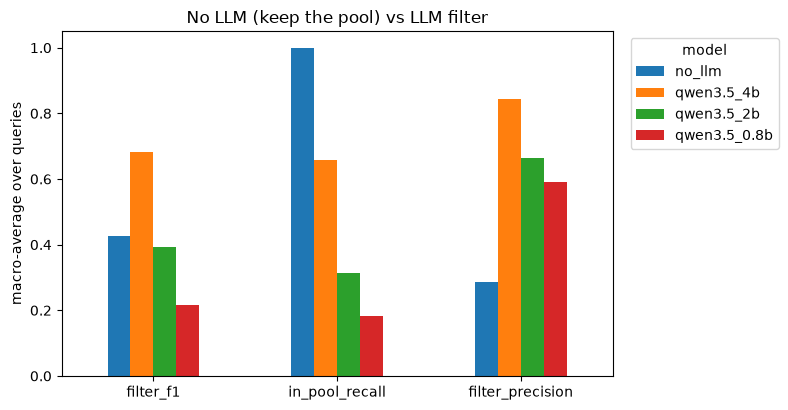

In [109]:
# Main headline metrics bar chart plot
headline_metrics = ["filter_f1", "in_pool_recall", "filter_precision"]
plot_df = results[results["metric"].isin(headline_metrics)]
pivot = plot_df.pivot(index="metric", columns="model", values="value")
pivot = pivot.reindex(index=headline_metrics, columns=plot_models)

ax = pivot.plot(kind="bar", figsize=(8, 4.2), rot=0)
ax.set_ylim(0, 1.05)
ax.set_ylabel("macro-average over queries")
ax.set_xlabel("")
ax.set_title("No LLM (keep the pool) vs LLM filter")
ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


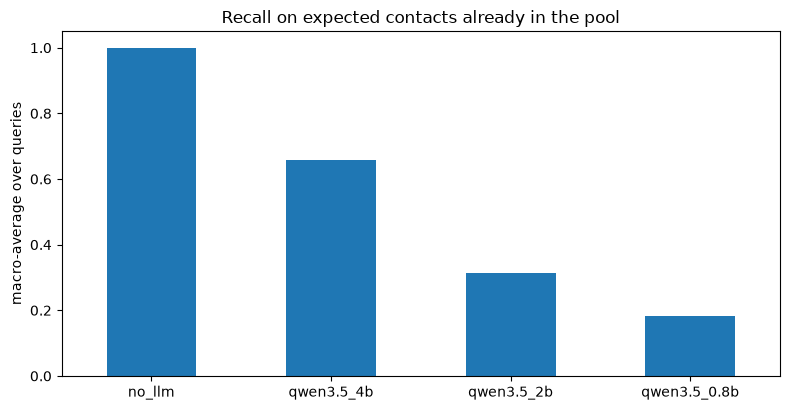

In [110]:
# no_llm keeps every expected id already in the pool, so this is 1.0 for the baseline
plot_df = results[results["metric"] == "in_pool_recall"]
pivot = plot_df.pivot(index="model", columns="metric", values="value")
pivot = pivot.reindex(index=plot_models)

ax = pivot.plot(kind="bar", figsize=(8, 4.2), rot=0, legend=False)
ax.set_ylim(0, 1.05)
ax.set_ylabel("macro-average over queries")
ax.set_xlabel("")
ax.set_title("Recall on expected contacts already in the pool")
plt.tight_layout()
plt.show()


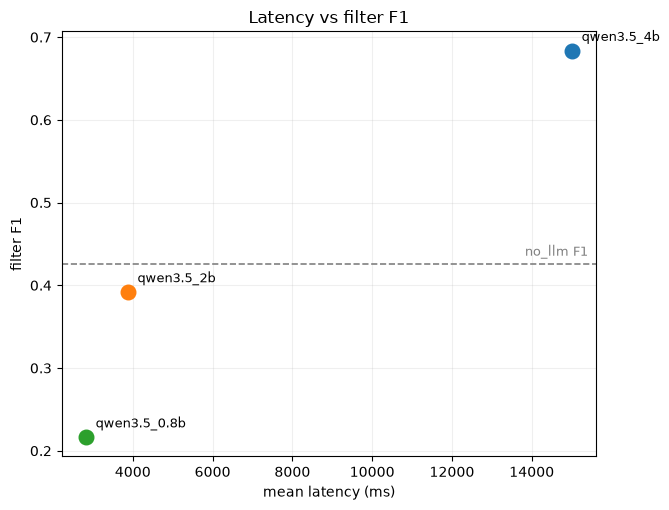

In [111]:
# Plot filter F1 against mean latency and compare to the no_llm baseline
plot_df = results[results["metric"] == "filter_f1"].copy()

llm_df = plot_df[plot_df["model"].isin(llm_models)].copy()
llm_df = llm_df.dropna(subset=["latency_ms_mean", "value"])

baseline_df = plot_df[plot_df["model"] == BASELINE_MODEL]
baseline_f1 = baseline_df["value"].iloc[0] if not baseline_df.empty else None

fig, ax = plt.subplots(figsize=(6.8, 5.2))

for model in llm_models:
    model_df = llm_df[llm_df["model"] == model]
    if model_df.empty:
        continue

    latency = model_df["latency_ms_mean"].iloc[0]
    f1 = model_df["value"].iloc[0]
    ax.scatter(latency, f1, s=110, zorder=3)
    ax.annotate(
        model,
        xy=(latency, f1),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
        )

if baseline_f1 is not None:
    ax.axhline(
        baseline_f1,
        color="grey",
        linestyle="--",
        linewidth=1.2,
    )
    ax.annotate(
        f"{BASELINE_MODEL} F1",
        xy=(1.0, baseline_f1),
        xycoords=("axes fraction", "data"),
        xytext=(-6, 6),
        textcoords="offset points",
        ha="right",
        fontsize=9,
        color="grey",
    )

ax.set_xlabel("mean latency (ms)")
ax.set_ylabel("filter F1")
ax.set_title("Latency vs filter F1")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()